# **Data Practicum II**

**Investigating the Co-occurrence of Supply Chain Gaps that are Driven by Business Closures in the US**

### Week 3: Exploratory Data Analysis (EDA)


##**Data Loading**

In [ ]:
import pandas as pd
from pathlib import Path

df = pd.read_csv("df_merged.csv")

orig_shape = df.shape

# Filtering for years greater than 1999
numeric = pd.to_numeric(df['year'], errors='coerce')
year_int = numeric.where((numeric >= 1900) & (numeric <= 2100)).astype('Int64')
df['year'] = year_int
df = df[df['year'].notna() & (df['year'] > 1999)].copy()

# Converting the 'year' column to datetime for downstream operations
df['year'] = pd.to_datetime(df['year'].astype(int).astype(str) + '-01-01')

print(f"Original shape: {orig_shape}, after filtering year > 1999: {df.shape}")
print("Columns:", df.columns.tolist())
df.head()

Original shape: (470989, 33), after filtering year > 1999: (245779, 33)
Columns: ['Unnamed: 0', 'year', 'st', 'sector', 'fage', 'firms', 'estabs', 'emp', 'denom', 'estabs_entry', 'estabs_entry_rate', 'estabs_exit', 'estabs_exit_rate', 'job_creation', 'job_creation_births', 'job_creation_continuers', 'job_creation_rate_births', 'job_creation_rate', 'job_destruction', 'job_destruction_deaths', 'job_destruction_continuers', 'job_destruction_rate_deaths', 'job_destruction_rate', 'net_job_creation', 'net_job_creation_rate', 'reallocation_rate', 'firmdeath_firms', 'firmdeath_estabs', 'firmdeath_emp', 'sector_name', 'state_abbr', 'income', 'population']


,Unnamed: 0,year,st,sector,fage,firms,estabs,emp,denom,estabs_entry,...,net_job_creation,net_job_creation_rate,reallocation_rate,firmdeath_firms,firmdeath_estabs,firmdeath_emp,sector_name,state_abbr,income,population
22,22,2000-01-01,1,11,b) 1,45.0,45.0,290.0,347.0,0.0,...,-113.0,-32.564841,32.276657,18.0,18.0,151.0,"Agriculture, Forestry, Fishing and Hunting",AL,60570.0,4452.173
23,23,2001-01-01,1,11,b) 1,48.0,48.0,345.0,367.0,0.0,...,-44.0,-11.989101,25.068120,16.0,16.0,60.0,"Agriculture, Forestry, Fishing and Hunting",AL,58790.0,4467.634
24,24,2002-01-01,1,11,b) 1,30.0,31.0,108.0,115.0,0.0,...,-16.0,-13.913043,29.565217,4.0,4.0,11.0,"Agriculture, Forestry, Fishing and Hunting",AL,62100.0,4480.089
25,25,2003-01-01,1,11,b) 1,34.0,34.0,208.0,231.0,0.0,...,-46.0,-19.913420,30.303030,8.0,8.0,20.0,"Agriculture, Forestry, Fishing and Hunting",AL,60270.0,4503.491
26,26,2004-01-01,1,11,b) 1,28.0,28.0,108.0,112.0,0.0,...,-6.0,-5.357143,55.357143,9.0,9.0,23.0,"Agriculture, Forestry, Fishing and Hunting",AL,57810.0,4530.729


In [ ]:
# Checking for missing values
print("\nMissing values per column (only columns with missing data):")
missing = df.isna().sum()
print(missing[missing > 0])


Missing values per column (only columns with missing data):
Series([], dtype: int64)


## **Feature Engineering**

Features engineering focused on **sector-level business closures** that drive supply chain gaps. The metrics relate to firm and establishment deaths, labor market dynamics, and growth momentum—all grouped by sector and state to preserve the panel structure critical for supply chain analysis.

In [ ]:
import numpy as np

df = df.copy()

# Preparing primary closure targets
df['closure_target'] = df['firmdeath_firms']  # Direct target for LSTM
df['closure_rate'] = df['firmdeath_estabs'] / df['estabs']  # Calculating normalized establishment death rate
df['closure_rate_firms'] = df['firmdeath_firms'] / df['firms']  # Calculating normalized firm death rate

# Creating labor market stress and density indicators
df['employment_density'] = df['emp'] / df['population']
df['job_destruction_intensity'] = df['job_destruction'] / df['emp']

# Sorting data by panel structure: sector and state
group_cols = ['state_abbr', 'sector_name']
df = df.sort_values(group_cols + ['year'])

print("Closure targets and core metrics created:")
print(df[['state_abbr', 'sector_name', 'year', 'closure_target', 'closure_rate',
          'job_destruction_rate', 'employment_density']].head(10))

Closure targets and core metrics created:
      state_abbr                      sector_name       year  closure_target  \
17855         AK  Accommodation and Food Services 2000-01-01            39.0   
17901         AK  Accommodation and Food Services 2000-01-01            14.0   
17947         AK  Accommodation and Food Services 2000-01-01            14.0   
17993         AK  Accommodation and Food Services 2000-01-01             8.0   
18039         AK  Accommodation and Food Services 2000-01-01             6.0   
18085         AK  Accommodation and Food Services 2000-01-01            12.0   
18131         AK  Accommodation and Food Services 2000-01-01            15.0   
18177         AK  Accommodation and Food Services 2000-01-01             6.0   
18223         AK  Accommodation and Food Services 2000-01-01             3.0   
18269         AK  Accommodation and Food Services 2000-01-01             0.0   

       closure_rate  job_destruction_rate  employment_density  
17855      0.

In [ ]:
# Engineering temporal lag features by sector
# Adding lagged features, which capture historical dependencies critical for LSTM sequence modeling

lag_features = ['closure_rate', 'job_destruction_rate', 'reallocation_rate', 'net_job_creation_rate']
group_cols = ['state_abbr', 'sector_name']

for col in lag_features:
    for lag in [1, 2]:
        df[f'lag{lag}_{col}'] = df.groupby(group_cols)[col].shift(lag)

print(f"Lagged features created for {lag_features}")
print(f"Total lag features: {len(lag_features) * 2}")
print("\nSample lagged features:")
print(df[['state_abbr', 'sector_name', 'year', 'closure_rate', 'lag1_closure_rate',
          'lag2_closure_rate', 'job_destruction_rate', 'lag1_job_destruction_rate']].head(15))

Lagged features created for ['closure_rate', 'job_destruction_rate', 'reallocation_rate', 'net_job_creation_rate']
Total lag features: 8

Sample lagged features:
      state_abbr                      sector_name       year  closure_rate  \
17855         AK  Accommodation and Food Services 2000-01-01      0.402062   
17901         AK  Accommodation and Food Services 2000-01-01      0.194444   
17947         AK  Accommodation and Food Services 2000-01-01      0.177215   
17993         AK  Accommodation and Food Services 2000-01-01      0.097561   
18039         AK  Accommodation and Food Services 2000-01-01      0.076923   
18085         AK  Accommodation and Food Services 2000-01-01      0.053571   
18131         AK  Accommodation and Food Services 2000-01-01      0.087156   
18177         AK  Accommodation and Food Services 2000-01-01      0.040541   
18223         AK  Accommodation and Food Services 2000-01-01      0.029703   
18269         AK  Accommodation and Food Services 2000-01-

In [ ]:
# Engineering derived features, including moving averages and growth rates by sector
# Capturing momentum and cyclical patterns in closure risk within sectors

# Calculating 3-year rolling averages to smooth short-term volatility and reveal trends
df['ma3_closure_rate'] = df.groupby(group_cols)['closure_rate'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)
df['ma3_job_destruction_rate'] = df.groupby(group_cols)['job_destruction_rate'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

# Calculating year-over-year growth rates, capturing macro and sector momentum
df['income_yoy'] = df.groupby(group_cols)['income'].pct_change()
df['population_yoy'] = df.groupby(group_cols)['population'].pct_change()
df['employment_yoy'] = df.groupby(group_cols)['emp'].pct_change()

print("Derived features created:")
print("  - 3-year moving average for closure_rate and job_destruction_rate")
print("  - Year-over-year growth rates: income, population, employment")
print("\nSample derived features by sector:")
sample_sector = df[df['sector_name'].str.contains('Retail', na=False)].drop_duplicates('year').head(10)
print(sample_sector[['sector_name', 'year', 'closure_rate', 'ma3_closure_rate',
                      'income_yoy', 'population_yoy', 'employment_yoy']].to_string())

Derived features created:
  - 3-year moving average for closure_rate and job_destruction_rate
  - Year-over-year growth rates: income, population, employment

Sample derived features by sector:
        sector_name       year  closure_rate  ma3_closure_rate  income_yoy  population_yoy  employment_yoy
12427  Retail Trade 2000-01-01      0.359551          0.359551         NaN             NaN             NaN
12428  Retail Trade 2001-01-01      0.333333          0.135643    0.061532        0.009158       -0.978255
12429  Retail Trade 2002-01-01      0.217822          0.098071   -0.091326        0.013607       -0.979359
12430  Retail Trade 2003-01-01      0.231405          0.106672   -0.037861        0.009461       -0.954680
12431  Retail Trade 2004-01-01      0.230769          0.098068    0.036251        0.016767       -0.978248
12432  Retail Trade 2005-01-01      0.346535          0.133296   -0.013464        0.011619       -0.974861
12433  Retail Trade 2006-01-01      0.345238          0.1

In [ ]:
# Preparing a feature summary table and conducting correlation analysis

feature_table = pd.DataFrame([
    ['closure_target', 'Firm deaths (count)', 'Actual business closures in sector'],
    ['closure_rate', 'Estab. deaths / Estabs', 'Normalized closure intensity by sector'],
    ['closure_rate_firms', 'Firm deaths / Firms', 'Firm-level closure intensity by sector'],
    ['job_destruction_rate', 'Job destruction rate', 'Labor market stress leading indicator'],
    ['net_job_creation_rate', 'Net job creation rate', 'Sector labor market momentum'],
    ['reallocation_rate', 'Reallocation rate', 'Structural churn within sector'],
    ['lag1_closure_rate', 'Previous-year closure rate', 'LSTM temporal dependency (t-1)'],
    ['lag2_closure_rate', 'Prior 2-year closure rate', 'LSTM temporal dependency (t-2)'],
    ['ma3_closure_rate', '3-year MA of closure rate', 'Smoothed trend in sector closures'],
    ['income', 'Median income', 'Proxy for local demand in sector'],
    ['population', 'Population', 'Market size and labor pool'],
    ['income_yoy', 'Income growth (YoY)', 'Demand momentum by sector'],
    ['population_yoy', 'Population growth (YoY)', 'Demographic momentum'],
    ['employment_density', 'Employment / population', 'Sector concentration in local area'],
], columns=['feature', 'definition', 'supply chain relevance'])

print("Selected Features for Sector-Level Closure Prediction:")
display(feature_table)

Selected Features for Sector-Level Closure Prediction:


,feature,definition,supply chain relevance
0,closure_target,Firm deaths (count),Actual business closures in sector
1,closure_rate,Estab. deaths / Estabs,Normalized closure intensity by sector
2,closure_rate_firms,Firm deaths / Firms,Firm-level closure intensity by sector
3,job_destruction_rate,Job destruction rate,Labor market stress leading indicator
4,net_job_creation_rate,Net job creation rate,Sector labor market momentum
5,reallocation_rate,Reallocation rate,Structural churn within sector
6,lag1_closure_rate,Previous-year closure rate,LSTM temporal dependency (t-1)
7,lag2_closure_rate,Prior 2-year closure rate,LSTM temporal dependency (t-2)
8,ma3_closure_rate,3-year MA of closure rate,Smoothed trend in sector closures
9,income,Median income,Proxy for local demand in sector


## **EDA**

### **State Time Series Comparison of Business Closure Rates**

This analysis visualizes the normalized firm death rates (`closure_rate_firms`) for states with historically high and low closure activity. This allows for a direct visual comparison of their temporal patterns.

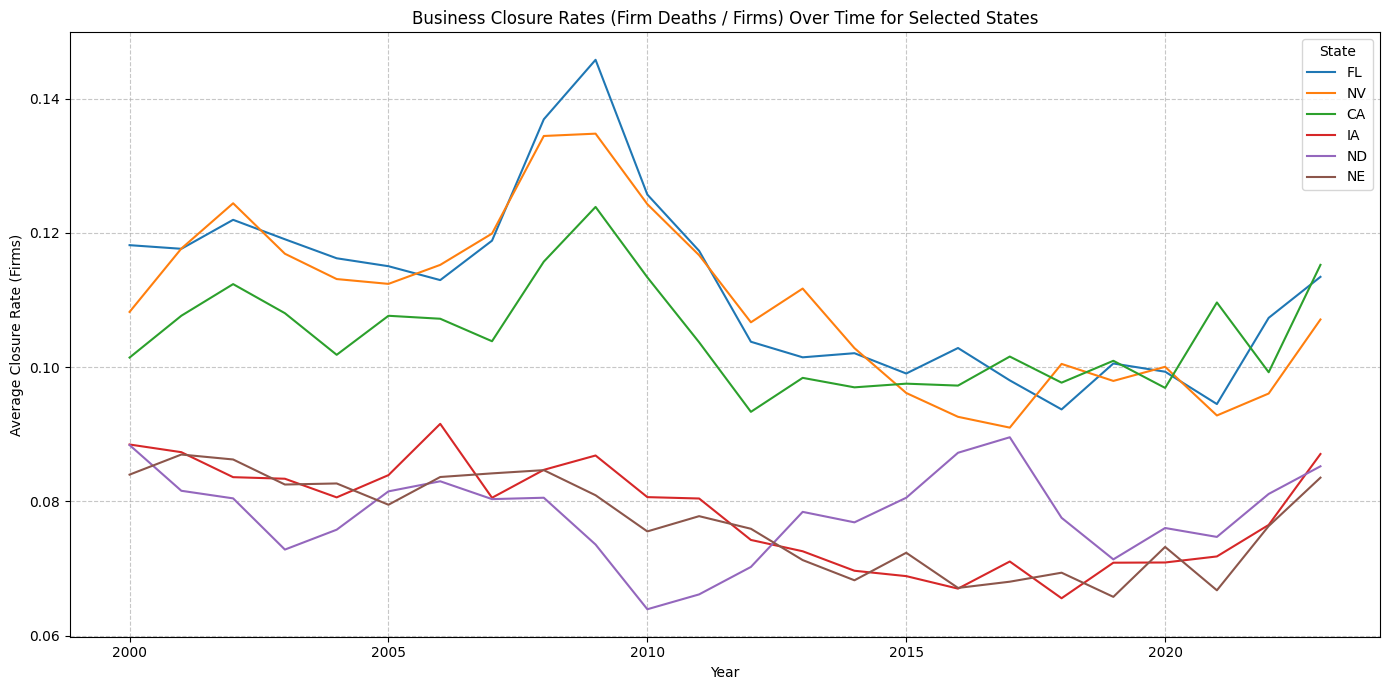

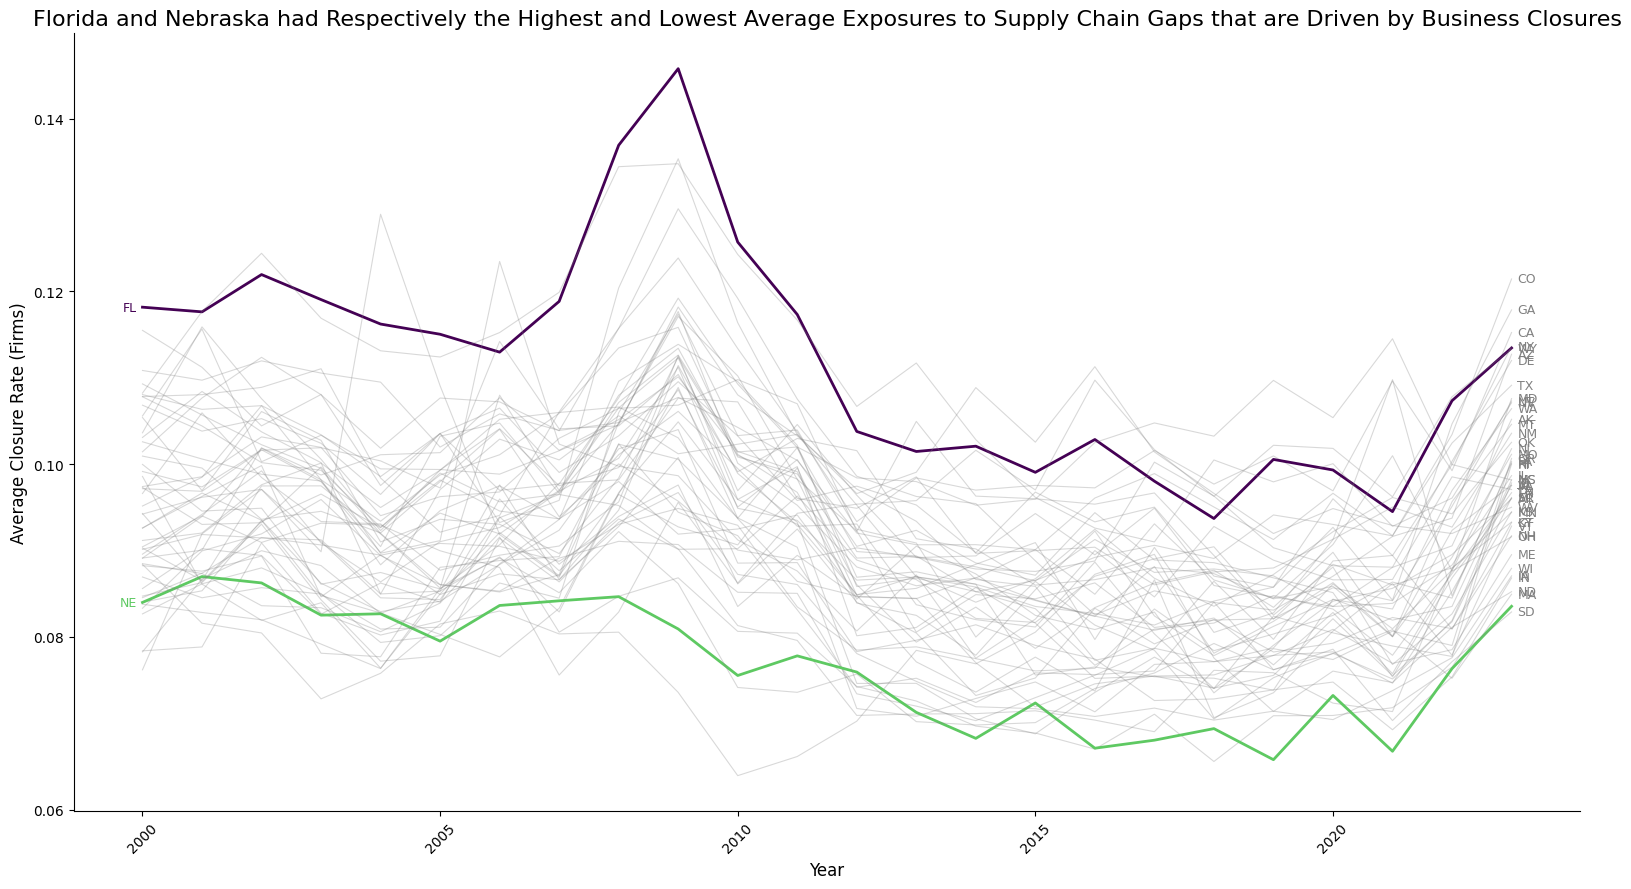

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating average closure_rate_firms per state to identify states with high/low rates
state_avg_closure_rate = df.groupby('state_abbr')['closure_rate_firms'].mean().sort_values(ascending=False)

# Selecting top 3 and bottom 3 states for visualization (adjust as needed)
top_states = state_avg_closure_rate.head(3).index.tolist()
bottom_states = state_avg_closure_rate.tail(3).index.tolist()
selected_states = top_states + bottom_states

plt.figure(figsize=(14, 7))
# Iterating through selected states and plotting their closure rates over time
for state in selected_states:
    state_data = df[df['state_abbr'] == state].groupby(df['year'].dt.year)['closure_rate_firms'].mean().reset_index()
    sns.lineplot(x='year', y='closure_rate_firms', data=state_data, label=state)

# Setting plot title and labels
plt.title('Business Closure Rates (Firm Deaths / Firms) Over Time for Selected States')
plt.xlabel('Year')
plt.ylabel('Average Closure Rate (Firms)')
# Adding a legend
plt.legend(title='State')
# Adding a grid
plt.grid(True, linestyle='--', alpha=0.7)
# Adjusting layout for better presentation
plt.tight_layout()
plt.show()


# --- Second Plot: All States with Highlighted High/Low Average Closure Rate ---

# Prepare data for all states by year
all_states_data_yearly_avg = df.groupby(['state_abbr', df['year'].dt.year])['closure_rate_firms'].mean().reset_index()
all_states_data_yearly_avg.rename(columns={'year': 'Year'}, inplace=True)

# Calculate the overall average closure rate for each state to identify high/low states
overall_state_avg_closure_rate = all_states_data_yearly_avg.groupby('state_abbr')['closure_rate_firms'].mean().sort_values(ascending=False)

# Identify states with highest and lowest overall average closure rates
highest_avg_closure_state = overall_state_avg_closure_rate.index[0]
lowest_avg_closure_state = overall_state_avg_closure_rate.index[-1]

plt.figure(figsize=(16, 9))

# Plot all states, with colors based on average closure rate
for state in all_states_data_yearly_avg['state_abbr'].unique():
    state_df = all_states_data_yearly_avg[all_states_data_yearly_avg['state_abbr'] == state]

    if state == highest_avg_closure_state:
        color = '#440154'
        linewidth = 2
        alpha = 1
        # Place label on the left for highest average closure state
        x_pos = state_df['Year'].iloc[0] - 0.1
        ha_align = 'right'
    elif state == lowest_avg_closure_state:
        color = '#5ec962'
        linewidth = 2
        alpha = 1
        # Place label on the left for lowest average closure state
        x_pos = state_df['Year'].iloc[0] - 0.1
        ha_align = 'right'
    else:
        color = 'grey'
        linewidth = 0.8
        alpha = 0.3
        # Place label on the right for other states
        x_pos = state_df['Year'].iloc[-1] + 0.1
        ha_align = 'left'

    sns.lineplot(x='Year', y='closure_rate_firms', data=state_df, color=color, linewidth=linewidth, alpha=alpha)

    # Add state abbreviation label
    # For highest and lowest, use the first year's data for placement.
    # For others, use the last year's data for placement.
    if state == highest_avg_closure_state or state == lowest_avg_closure_state:
        first_year_data = state_df[state_df['Year'] == state_df['Year'].min()]
        if not first_year_data.empty:
            plt.text(x_pos, first_year_data['closure_rate_firms'].iloc[0],
                     state, color=color, fontsize=9, ha=ha_align, va='center')
    else:
        last_year_data = state_df[state_df['Year'] == state_df['Year'].max()]
        if not last_year_data.empty:
            plt.text(x_pos, last_year_data['closure_rate_firms'].iloc[0],
                     state, color=color, fontsize=9, ha=ha_align, va='center')

plt.title('Florida and Nebraska had Respectively the Highest and Lowest Average Exposures to Supply Chain Gaps that are Driven by Business Closures',
          fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Closure Rate (Firms)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False) # Remove grid lines as requested
sns.despine() # Remove top and right frames
plt.show()

## Insights State Time Series Comparison of Business Closure Rates

*   **DESCRIBE:** The line chart illustrates the average business closure rates (firm deaths per firms) from 2000 to 2023 for the three states with the highest rates (Florida, Nevada, California) and the three states with the lowest rates (Iowa, North Dakota, Nebraska). The top states consistently show higher closure rates and greater year-to-year variability, while the bottom states maintain relatively lower and more stable rates.
*   **INTERPRET:** States with generally higher closure rates and more fluctuations might indicate a more dynamic or volatile business environment. States with lower, more stable rates likely have more resilient or less disruption-prone economies. Businesses operating in high-volatility states face greater risk, while those in low-volatility states might offer more predictable operations but potentially slower growth.
*   **RECOMMEND:** Businesses should conduct thorough risk assessments when considering operations or supply chain partners in states with historically high and volatile closure rates. Policy makers in high-volatility states could explore targeted economic incentives or support programs to stabilize local businesses during periods of increased closure rates.

### **Sector Time Series Comparison of Business Closure Rates**

This EDA visualizes normalized firm death rates (`closure_rate_firms`) by sector over time.

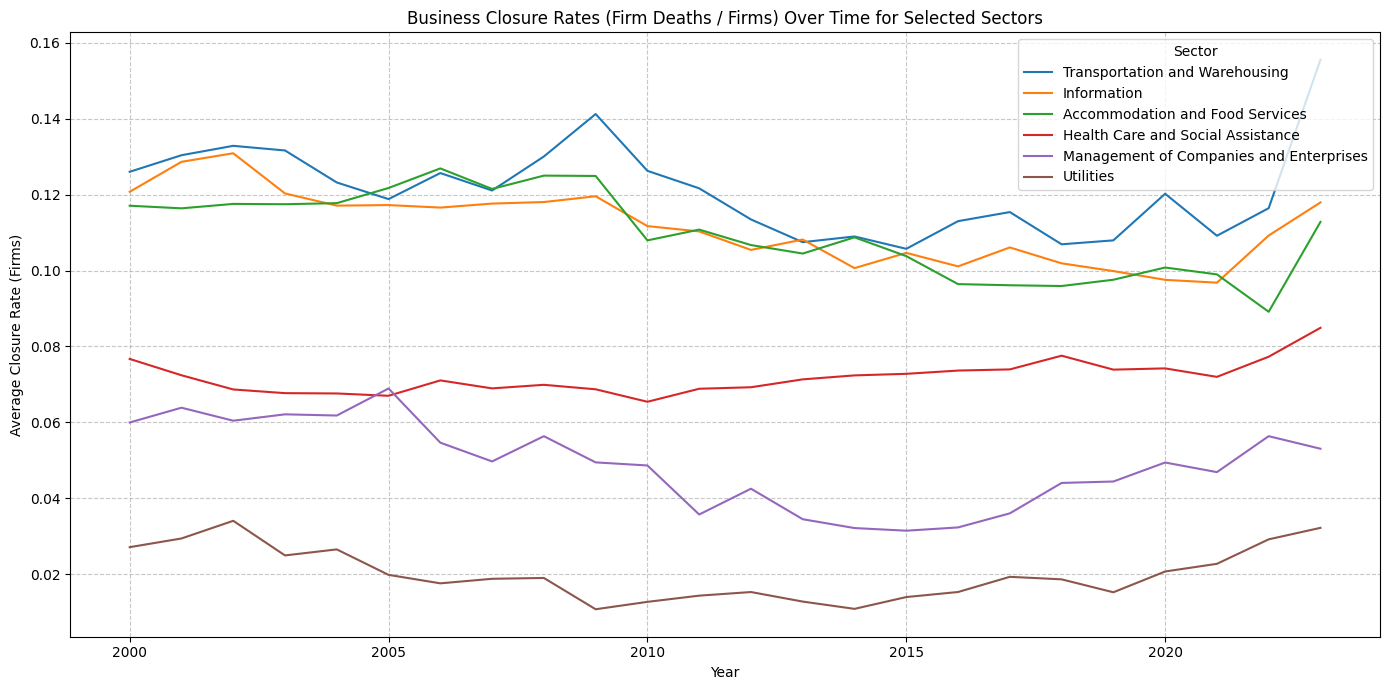

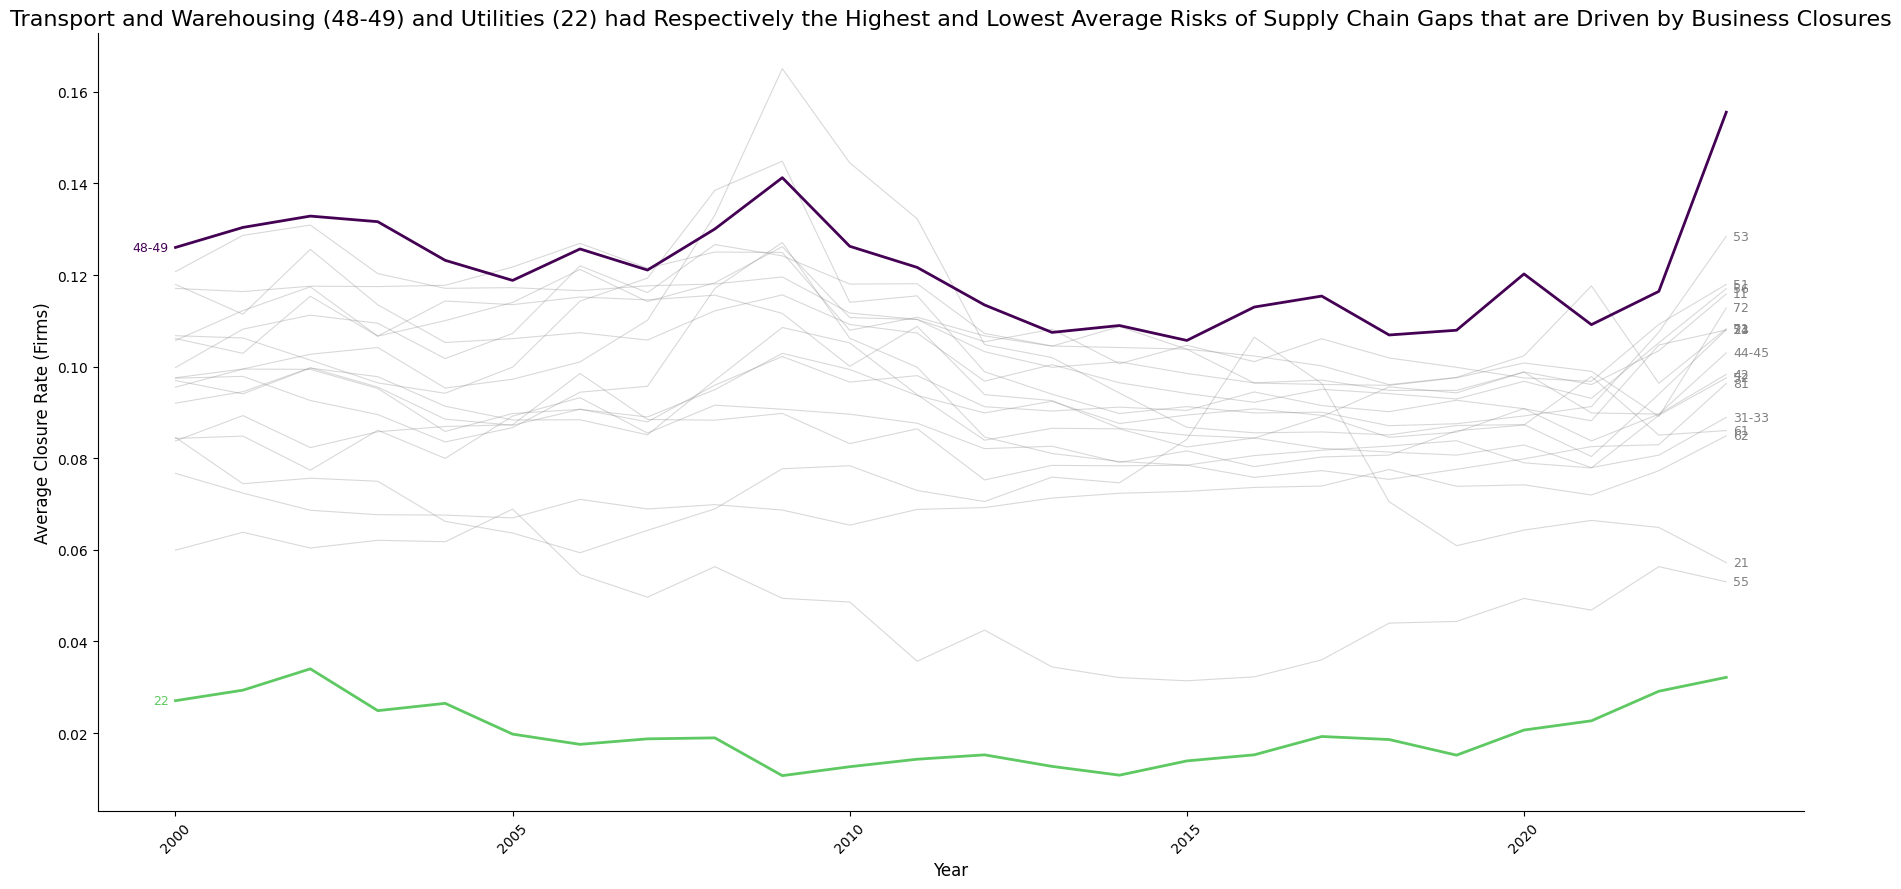

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating average closure_rate_firms per sector to identify sectors with high/low rates
sector_avg_closure_rate = df.groupby('sector_name')['closure_rate_firms'].mean().sort_values(ascending=False)

# Selecting top 3 and bottom 3 sectors for visualization
top_sectors = sector_avg_closure_rate.head(3).index.tolist()
bottom_sectors = sector_avg_closure_rate.tail(3).index.tolist()
selected_sectors_for_eda = top_sectors + bottom_sectors

plt.figure(figsize=(14, 7))
# Iterating through selected sectors and plotting their closure rates over time
for sector in selected_sectors_for_eda:
    sector_data = df[df['sector_name'] == sector].groupby(df['year'].dt.year)['closure_rate_firms'].mean().reset_index()
    sns.lineplot(x='year', y='closure_rate_firms', data=sector_data, label=sector)

# Setting plot title and labels
plt.title('Business Closure Rates (Firm Deaths / Firms) Over Time for Selected Sectors')
plt.xlabel('Year')
plt.ylabel('Average Closure Rate (Firms)')
# Adding a legend
plt.legend(title='Sector')
# Adding a grid
plt.grid(True, linestyle='--', alpha=0.7)
# Adjusting layout for better presentation
plt.tight_layout()
plt.show()


# --- Second Plot: All Sectors with Highlighted High/Low Average Closure Rate ---

# Prepare data for all sectors by year
all_sectors_data_yearly_avg = df.groupby(['sector_name', df['year'].dt.year])['closure_rate_firms'].mean().reset_index()
all_sectors_data_yearly_avg.rename(columns={'year': 'Year'}, inplace=True)

# Calculate the overall average closure rate for each sector to identify high/low sectors
overall_sector_avg_closure_rate = all_sectors_data_yearly_avg.groupby('sector_name')['closure_rate_firms'].mean().sort_values(ascending=False)

# Identify sectors with highest and lowest overall average closure rates
highest_avg_closure_sector = overall_sector_avg_closure_rate.index[0]
lowest_avg_closure_sector = overall_sector_avg_closure_rate.index[-1]

plt.figure(figsize=(18, 9))

# Define NAICS 2017 Codes and their corresponding sector names for direct labels
naics_mapping = {
    '11': 'Agriculture, Forestry, Fishing and Hunting',
    '21': 'Mining, Quarrying, and Oil and Gas Extraction',
    '22': 'Utilities',
    '23': 'Construction',
    '31-33': 'Manufacturing',
    '42': 'Wholesale Trade',
    '44-45': 'Retail Trade',
    '48-49': 'Transportation and Warehousing',
    '51': 'Information',
    '52': 'Finance and Insurance',
    '53': 'Real Estate and Rental and Leasing',
    '54': 'Professional, Scientific, and Technical Services',
    '55': 'Management of Companies and Enterprises',
    '56': 'Administrative and Support and Waste Management and Remediation Services',
    '61': 'Educational Services',
    '62': 'Health Care and Social Assistance',
    '71': 'Arts, Entertainment, and Recreation',
    '72': 'Accommodation and Food Services',
    '81': 'Other Services (except Public Administration)'
}

# Create a reverse mapping for node labels, converting full sector names to NAICS codes
sector_to_naics = {v: k for k, v in naics_mapping.items()}

# Plot all sectors, with colors based on average closure rate
for sector in all_sectors_data_yearly_avg['sector_name'].unique():
    sector_df = all_sectors_data_yearly_avg[all_sectors_data_yearly_avg['sector_name'] == sector]

    if sector == highest_avg_closure_sector:
        color = '#440154'
        linewidth = 2
        alpha = 1
        # Place label on the left for highest average closure sector
        x_pos = sector_df['Year'].iloc[0] - 0.1
        ha_align = 'right'
    elif sector == lowest_avg_closure_sector:
        color = '#5ec962'
        linewidth = 2
        alpha = 1
        # Place label on the left for lowest average closure sector
        x_pos = sector_df['Year'].iloc[0] - 0.1
        ha_align = 'right'
    else:
        color = 'grey'
        linewidth = 0.8
        alpha = 0.3
        # Place label on the right for other sectors
        x_pos = sector_df['Year'].iloc[-1] + 0.1
        ha_align = 'left'

    sns.lineplot(x='Year', y='closure_rate_firms', data=sector_df, color=color, linewidth=linewidth, alpha=alpha)

    # Add sector abbreviation (NAICS code) label
    naics_code = sector_to_naics.get(sector, sector) # Get NAICS code or use full name if not found

    if sector == highest_avg_closure_sector or sector == lowest_avg_closure_sector:
        first_year_data = sector_df[sector_df['Year'] == sector_df['Year'].min()]
        if not first_year_data.empty:
            plt.text(x_pos, first_year_data['closure_rate_firms'].iloc[0],
                     naics_code, color=color, fontsize=9, ha=ha_align, va='center')
    else:
        last_year_data = sector_df[sector_df['Year'] == sector_df['Year'].max()]
        if not last_year_data.empty:
            plt.text(x_pos, last_year_data['closure_rate_firms'].iloc[0],
                     naics_code, color=color, fontsize=9, ha=ha_align, va='center')

plt.title('Transport and Warehousing (48-49) and Utilities (22) had Respectively the Highest and Lowest Average Risks of Supply Chain Gaps that are Driven by Business Closures',
          fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Closure Rate (Firms)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False) # Remove grid lines as requested
sns.despine() # Remove top and right frames
plt.show()

## Insights for Sector Time Series Comparison of Business Closure Rates

*   **DESCRIBE:** The line chart illustrates the average business closure rates (firm deaths per firms) from 2000 to 2023 for the three sectors with the highest rates (Transportation and Warehousing, Information, Accommodation and Food Services) and the three sectors with the lowest rates (Health Care and Social Assistance, Management of Companies and Enterprises, Utilities). The top sectors consistently exhibit higher closure rates and often show greater year-to-year variability, particularly Accommodation and Food Services. Conversely, the bottom sectors maintain relatively lower and more stable rates.
*   **INTERPRET:** Sectors with consistently higher closure rates and greater fluctuations, such as Accommodation and Food Services, suggest an inherently more dynamic or volatile business environment. This could be due to lower barriers to entry, high competition, or sensitivity to economic shifts. In contrast, sectors with lower, more stable rates likely possess greater resilience. For supply chain analysis, this indicates that disruptions are more probable within or impacting businesses in high-volatility sectors.
*   **RECOMMEND:** Businesses with significant supply chain dependencies on high-volatility sectors, such as Accommodation and Food Services, should implement robust contingency plans and consider diversifying their supplier base. Policymakers and investors looking for stability might favor sectors like Educational Services or Utilities, recognizing their potentially slower growth but higher resilience.

### **State-Sector Top Combinations by Average Business Closure Rate**

To identify which state and sector combinations experience high business closures, this analysis ranked and visualized the top 15 state-sector pairs with the highest average `closure_rate_firms` across all years. This aimed to highlight specific regional-industry vulnerabilities.

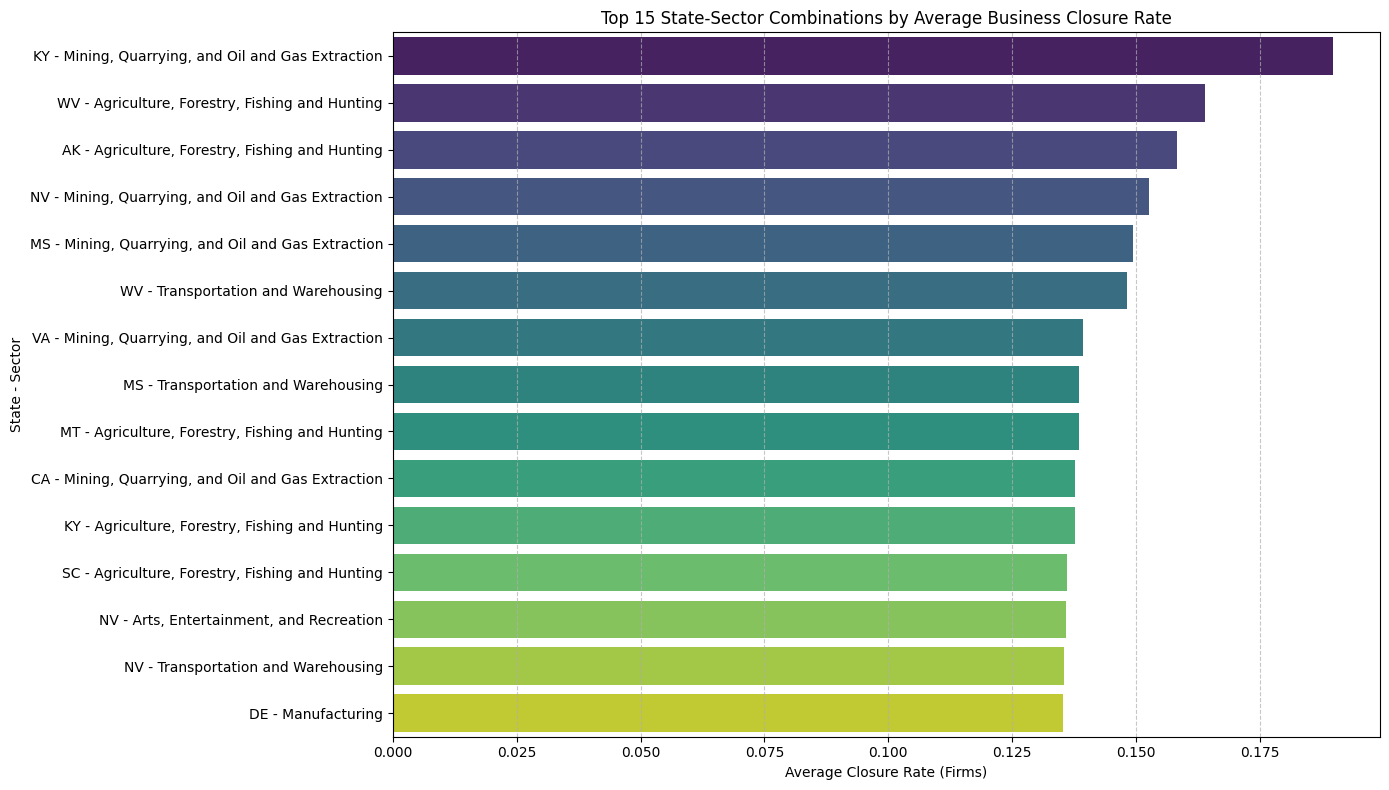

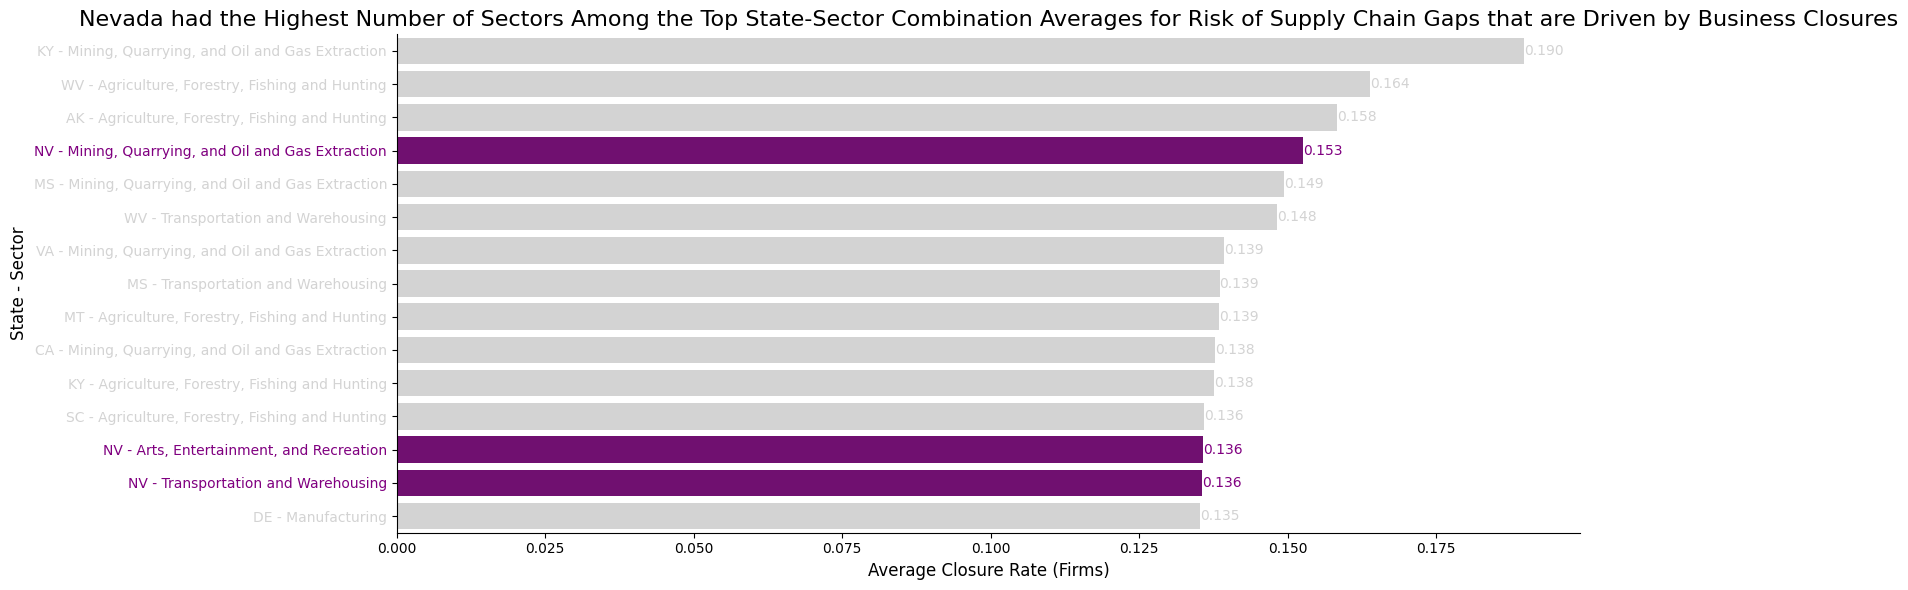

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating average closure_rate_firms for each state-sector combination
state_sector_closure_rates = df.groupby(['state_abbr', 'sector_name'])['closure_rate_firms'].mean().reset_index()
# Combining state and sector names for easier plotting
state_sector_closure_rates['state_sector'] = state_sector_closure_rates['state_abbr'] + ' - ' + state_sector_closure_rates['sector_name']

# Identifying the top 15 state-sector combinations by closure rate
top_15_state_sector_closures = state_sector_closure_rates.nlargest(15, 'closure_rate_firms')

plt.figure(figsize=(14, 8))
# Plotting the bar chart
sns.barplot(x='closure_rate_firms', y='state_sector', data=top_15_state_sector_closures, palette='viridis', hue='state_sector', legend=False)
# Setting plot title and labels
plt.title('Top 15 State-Sector Combinations by Average Business Closure Rate')
plt.xlabel('Average Closure Rate (Firms)')
plt.ylabel('State - Sector')
# Adding a grid
plt.grid(axis='x', linestyle='--', alpha=0.7)
# Adjusting layout for better presentation
plt.tight_layout()
plt.show()


# --- Second Bar Chart: Highlighting the Most Common State ---

plt.figure(figsize=(16, 6))

# Identify the most common state in the top 15 combinations
most_common_state = top_15_state_sector_closures['state_abbr'].value_counts().idxmax()

# Assign colors based on whether the state in the combination is the most common one
colors = ['purple' if state == most_common_state else 'lightgrey' for state in top_15_state_sector_closures['state_abbr']]

ax = sns.barplot(x='closure_rate_firms', y='state_sector', data=top_15_state_sector_closures, palette=colors, hue='state_sector', legend=False)

# Add data labels to the bars, with colors corresponding to the bars
for i, bar in enumerate(ax.patches):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, # x, y coordinates
            f'{bar.get_width():.3f}', # Label text (formatted value)
            va='center', ha='left', # Vertical and horizontal alignment
            color=colors[i], fontsize=10) # Set color from the 'colors' list

# Adjust the y-axis tick labels to correspond with the bar colors
for i, label in enumerate(ax.get_yticklabels()):
    label.set_color(colors[i])

plt.title(f'Nevada had the Highest Number of Sectors Among the Top State-Sector Combination Averages for Risk of Supply Chain Gaps that are Driven by Business Closures',
          fontsize=16)
plt.xlabel('Average Closure Rate (Firms)', fontsize=12)
plt.ylabel('State - Sector', fontsize=12)
plt.tight_layout()
plt.grid(False) # Remove grid lines
sns.despine() # Remove top and right frames
plt.show()

## Insights for State-Sector Top Combinations by Average Business Closure Rate

*   **DESCRIBE:** The bar chart highlights the top 15 state-sector combinations with the highest average business closure rates (firm deaths per firms) from 2000 to 2023. Notably, the **Agriculture, Forestry, Fishing and Hunting and the Mining, Quarrying, and Oil and Gas Extraction sectors are highly dominant, appearing 5 times each** within these top 15 combinations. Kentucky's Mining, Quarrying, and Oil and Gas Extraction sector shows the highest average closure rate, followed by two Agriculture, Forestry, Fishing and Hunting combinations for West Virginia and Alaska. Other sectors like Manufacturing, Arts, Entertainment, and Recreation, and Transportation and Warehousing are also present in this list.
*   **INTERPRET:** This visualization pinpoints specific geographical and industrial vulnerabilities where business closures are most prevalent. These combinations represent hotspots of instability, potentially indicating regions where local economic conditions or industry-specific challenges disproportionately affect business survival. For supply chain managers, these are critical areas to monitor for potential disruptions.
*   **RECOMMEND:** Businesses should avoid over-reliance on single suppliers or partners located within these top-ranked, high-closure-rate state-sector combinations. Governments and economic development agencies in these regions could investigate the underlying causes of high closure rates to develop targeted interventions and support programs.

### **State-Specific Top Closure Sectors & Co-occurrence Network**

This analysis identifies, for each state and year, the sector that experienced the highest business closure rate. Following this, a network graph was constructed to visualize connections between states. States will be connected if they shared the same top-closure sector in a given year. The thickness of the edge indicated how many times they shared a top-closure sector, and the size of each state's node reflected its total sum of closures over the years.

In [ ]:
%pip install python-louvain

In [ ]:
%pip install netgraph


Part 1: Sector with the Highest Closure Rate per State per Year


,year,state_abbr,sector_name,closure_rate_firms
0,2000-01-01,AK,"Agriculture, Forestry, Fishing and Hunting",0.800000
1,2000-01-01,AL,Management of Companies and Enterprises,0.571429
2,2000-01-01,AR,Educational Services,0.631579
3,2000-01-01,AZ,"Mining, Quarrying, and Oil and Gas Extraction",0.571429
4,2000-01-01,CA,"Mining, Quarrying, and Oil and Gas Extraction",0.500000
5,2000-01-01,CO,"Agriculture, Forestry, Fishing and Hunting",0.500000
6,2000-01-01,CT,"Agriculture, Forestry, Fishing and Hunting",0.600000
7,2000-01-01,DE,Manufacturing,0.550000
8,2000-01-01,FL,Utilities,0.681818
9,2000-01-01,GA,"Mining, Quarrying, and Oil and Gas Extraction",0.916667



Part 2: Network Graph of State Co-occurrence


/usr/local/lib/python3.12/dist-packages/netgraph/_node_layout.py:1024: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/netgraph/_edge_layout.py:978: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/netgraph/_utils.py:360: RuntimeWarning:

invalid value encountered in divide



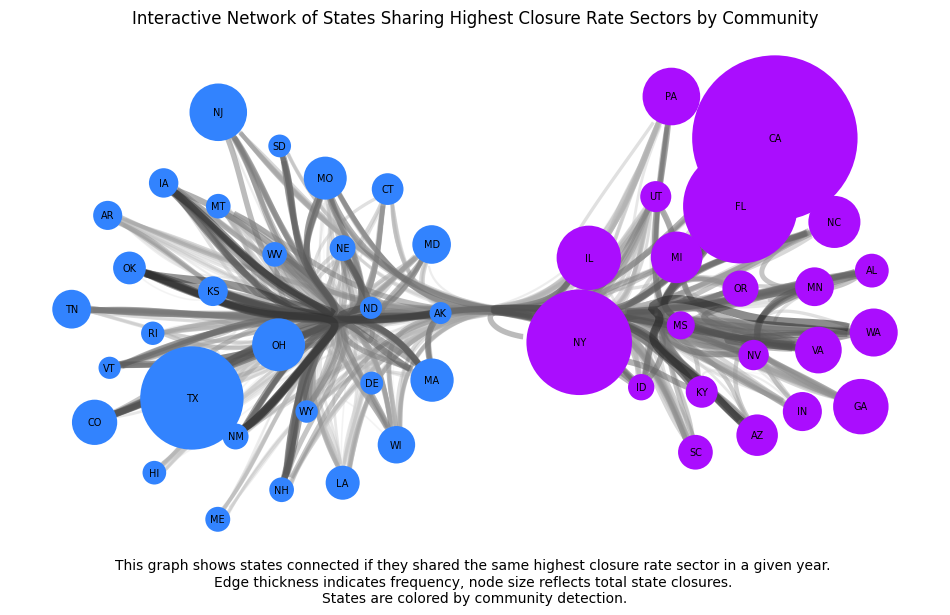

In [ ]:
import community.community_louvain as co
import networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt
from netgraph import Graph # Importing Graph from netgraph
import plotly.express as px

# Indicating the start of Part 1: Table of Highest Closure Rate Sector per State per Year
print("\nPart 1: Sector with the Highest Closure Rate per State per Year")

# Sorting by closure_rate_firms in descending order to facilitate picking the top sector
df_sorted = df.sort_values(['year', 'state_abbr', 'closure_rate_firms'], ascending=[True, True, False])

# Grouping by year and state, then taking the first entry
df_top_sector_per_state_year = df_sorted.groupby(['year', 'state_abbr']).first().reset_index()
df_top_sector_per_state_year = df_top_sector_per_state_year[['year', 'state_abbr', 'sector_name', 'closure_rate_firms']]

display(df_top_sector_per_state_year.head(10))

# Indicating the start of Part 2: Network Graph of State Co-occurrence Based on Top Closure Sectors (using netgraph)
print("\nPart 2: Network Graph of State Co-occurrence")

# Calculating edge weights, indicating the number of times states share the same top closure sector
shared_sector_counts = defaultdict(int)
for year in df_top_sector_per_state_year['year'].unique():
    yearly_data = df_top_sector_per_state_year[df_top_sector_per_state_year['year'] == year]

    # Grouping by sector_name to identify states that share the same top sector in that year
    for sector, group in yearly_data.groupby('sector_name'):
        states_in_group = sorted(group['state_abbr'].tolist())
        if len(states_in_group) > 1:
            # Creating all possible unique pairs of states within this group
            for i in range(len(states_in_group)):
                for j in range(i + 1, len(states_in_group)):
                    pair = tuple(sorted((states_in_group[i], states_in_group[j])))
                    shared_sector_counts[pair] += 1

# Converting the data into a list of edges with weights, storing (u, v, count)
edges_data = [{'u': s1, 'v': s2, 'count': count} for (s1, s2), count in shared_sector_counts.items() if count > 0]

# Calculating node sizes, indicating total firm deaths per state
state_total_closures = df.groupby('state_abbr')['firmdeath_firms'].sum()

# Creating the NetworkX graph
G = nx.Graph()
for edge in edges_data:
    G.add_edge(edge['u'], edge['v'], weight=edge['count']) # Adding weight for layout if desired

# Filtering out states that are not connected in the graph (isolates)
isolates = list(nx.isolates(G))
G.remove_nodes_from(isolates)

# Performing community detection
partition = co.best_partition(G)
unique_communities = sorted(list(set(partition.values())))

# Mapping nodes to communities for netgraph's community layout
node_to_community = partition

# Generating colors for communities
community_colors_palette = px.colors.qualitative.Alphabet
community_color_map = {
    community_id: community_colors_palette[i % len(community_colors_palette)]
    for i, community_id in enumerate(unique_communities)
}

# Mapping each node to a color based on its community
node_color = {node: community_color_map[partition[node]] for node in G.nodes()}

# Scaling node sizes for netgraph
# Using netgraph's `node_size_by`, which expects a dictionary where keys are nodes and values are numerical sizes.
if not state_total_closures.empty:
    min_closures = state_total_closures.min()
    max_closures = state_total_closures.max()
    if max_closures == min_closures:
        # Setting a default size if all values are the same; netgraph uses 'node_size' for uniform size.
        node_size_by = {state: 5 for state in G.nodes()}
    else:
        # Adjusting the scaling factor to make nodes smaller (from 5-30 to 2-15)
        node_size_by = {state: 2 + 13 * (closures - min_closures) / (max_closures - min_closures)
                        for state, closures in state_total_closures.items() if state in G.nodes()}
else:
    node_size_by = {}

# Creating edge widths based on frequency for netgraph
# Using netgraph's `edge_width`, which takes a dictionary or a float. Defaulting to 0.1 for thin edges as per prior request.
edge_widths = {}
for u, v, data in G.edges(data=True):
    count = data['weight']
    # Frequency-based scaling for edge width, with a base of 0.1
    edge_widths[(u,v)] = 0.1 + count * 0.1 # Scaling edge width based on frequency


# Preparing node labels
node_labels = {node: node for node in G.nodes()} # Displaying state abbreviations as labels

fig, ax = plt.subplots(figsize=(12, 10)) # Adjusting figure size as needed

Graph(G,
      node_color=node_color, # Indicating the community each belongs to
      node_edge_width=0,     # Removing black border around nodes
      edge_width=edge_widths,        # Using calculated edge widths
      edge_alpha=0.5,        # Setting low edge alpha values to accentuate bundles as they appear darker than single edges
      node_layout='community', node_layout_kwargs=dict(node_to_community=node_to_community),
      node_size=node_size_by, # Using the calculated node sizes
      node_labels=node_labels,
      edge_layout='bundled',
      ax=ax,
)

ax.set_facecolor('white') # Setting the background to white

# Adding the title and explanation (static for netgraph)
ax.set_title('Interactive Network of States Sharing Highest Closure Rate Sectors by Community')
plt.text(0.5, -0.05,
         "This graph shows states connected if they shared the same highest closure rate sector in a given year. \nEdge thickness indicates frequency, node size reflects total state closures. \nStates are colored by community detection.",
         horizontalalignment='center',
         verticalalignment='center',
         transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.show()

## Insights for State-Specific Top Closure Sectors & Co-occurrence Network

*   **DESCRIBE:** This network graph illustrates the communities of states sharing the same highest business closure rate sector in any given year. States are represented as nodes, with their size proportional to their total historical firm deaths. Edges connect states that shared a top-closure sector, and the edge thickness indicates how often this co-occurrence happened. Nodes are color-coded by detected communities, grouping states with similar patterns of sector-specific closures.
*   **INTERPRET:** The communities highlight groups of states that are economically linked or face similar challenges, leading to synchronized sector-specific business closure patterns. States with larger nodes and thicker connections are either larger economies experiencing more closures, or they are frequently impacted by the same sector-specific issues as many other states. This can indicate contagion effects or shared vulnerabilities across regions.
*   **RECOMMEND:** For businesses, understanding these state communities and connections can help in assessing systemic risks. If a supplier or market is in a highly connected state or a dominant community, it might be susceptible to shared shocks. Policymakers can use community detection to identify regions that may benefit from collaborative economic development strategies or shared support programs when a specific sector faces widespread distress.

### **Sector-Specific Top Closure States & Co-occurrence Network**

This analysis identifies, for each sector and year, the state that experienced the highest business closure rate. Following this, a network graph was constructed to visualize connections between sectors. Sectors were connected if they shared the same top-closure state in a given year. The thickness of the edge indicates how many times they shared a top-closure state, and the size of each sector's node reflect its total sum of closures over the years.


Part 1: State with the Highest Closure Rate per Sector per Year


,year,sector_name,state_abbr,closure_rate_firms
0,2000-01-01,Accommodation and Food Services,DE,0.500000
1,2000-01-01,Administrative and Support and Waste Managemen...,NV,0.555556
2,2000-01-01,"Agriculture, Forestry, Fishing and Hunting",ND,1.333333
3,2000-01-01,"Arts, Entertainment, and Recreation",MS,0.562500
4,2000-01-01,Construction,AK,0.381679
5,2000-01-01,Educational Services,AR,0.631579
6,2000-01-01,Finance and Insurance,SD,0.888889
7,2000-01-01,Health Care and Social Assistance,AK,0.296296
8,2000-01-01,Information,RI,0.555556
9,2000-01-01,Management of Companies and Enterprises,VT,2.000000



Part 2: Network Graph of Sector Co-occurrence


/usr/local/lib/python3.12/dist-packages/netgraph/_edge_layout.py:978: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/netgraph/_utils.py:360: RuntimeWarning:

invalid value encountered in divide



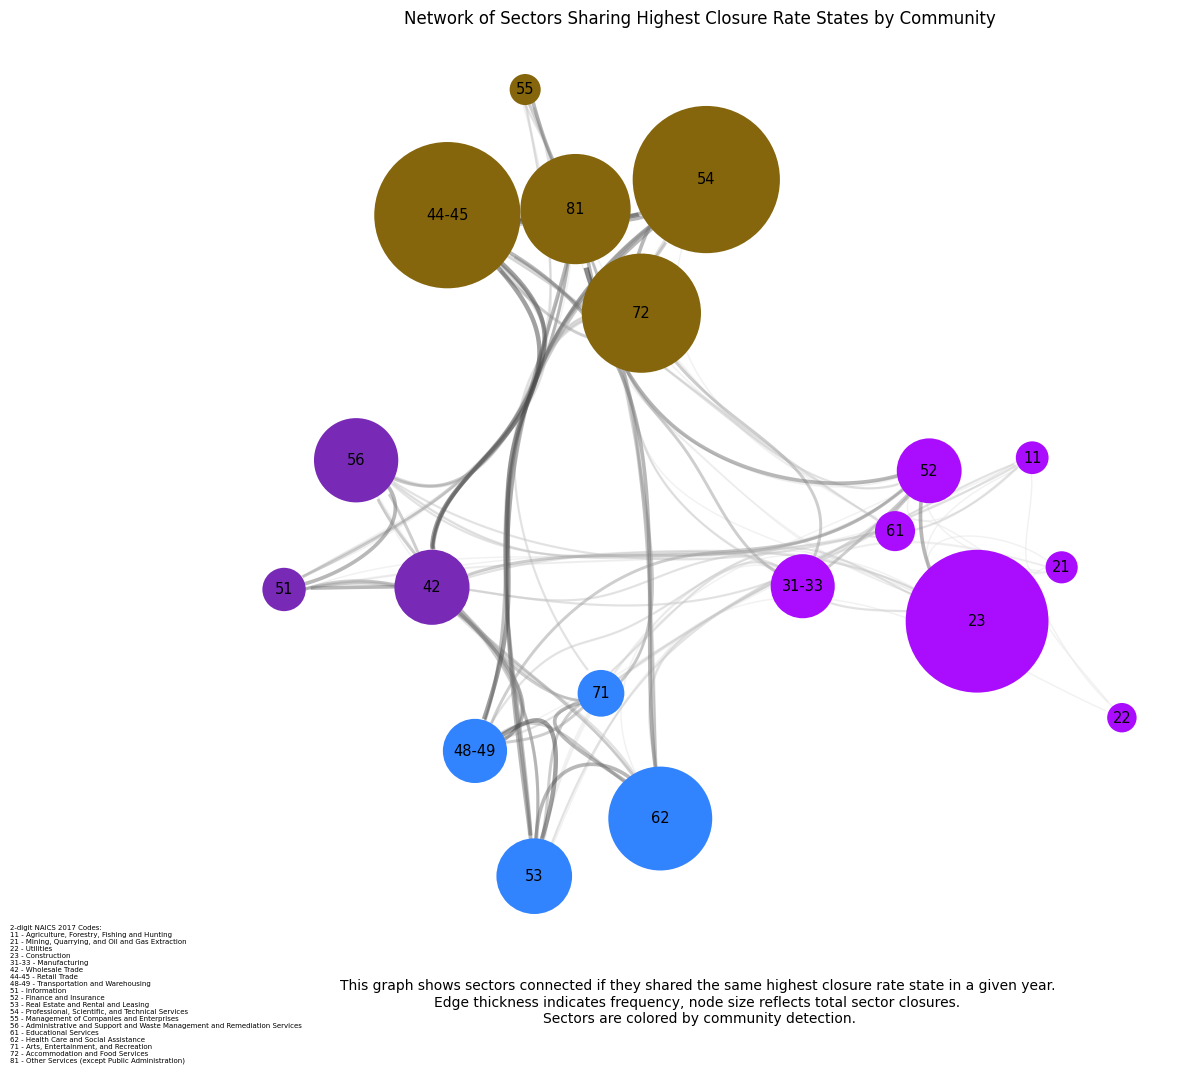

In [ ]:
import community.community_louvain as co
import networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt
from netgraph import Graph
import plotly.express as px

# Indicating the start of Part 1: Table of Highest Closure Rate State per Sector per Year
print("\nPart 1: State with the Highest Closure Rate per Sector per Year")

# Sorting by closure_rate_firms in descending order to facilitate picking the top state for each sector/year
df_sorted_by_sector_state = df.sort_values(['year', 'sector_name', 'closure_rate_firms'], ascending=[True, True, False])

# Grouping by year and sector, then taking the first entry (which represents the state with the top closure rate for that sector/year)
df_top_state_per_sector_year = df_sorted_by_sector_state.groupby(['year', 'sector_name']).first().reset_index()
df_top_state_per_sector_year = df_top_state_per_sector_year[['year', 'sector_name', 'state_abbr', 'closure_rate_firms']]

display(df_top_state_per_sector_year.head(10))

# Indicating the start of Part 2: Network Graph of Sector Co-occurrence Based on Top Closure States (using netgraph)
print("\nPart 2: Network Graph of Sector Co-occurrence")

# Calculating edge weights, indicating the number of times sectors share the same top closure state
shared_state_counts = defaultdict(int)
for year in df_top_state_per_sector_year['year'].unique():
    yearly_data = df_top_state_per_sector_year[df_top_state_per_sector_year['year'] == year]

    # Grouping by state_abbr to identify sectors that share the same top closure state in that year
    for state, group in yearly_data.groupby('state_abbr'):
        sectors_in_group = sorted(group['sector_name'].tolist())
        if len(sectors_in_group) > 1:
            # Creating all possible unique pairs of sectors within this group
            for i in range(len(sectors_in_group)):
                for j in range(i + 1, len(sectors_in_group)):
                    pair = tuple(sorted((sectors_in_group[i], sectors_in_group[j])))
                    shared_state_counts[pair] += 1

# Converting the data into a list of edges with weights, storing (u, v, count)
edges_data_sectors = [{'u': s1, 'v': s2, 'count': count} for (s1, s2), count in shared_state_counts.items() if count > 0]

# Calculating node sizes, indicating total firm deaths per sector
sector_total_closures = df.groupby('sector_name')['firmdeath_firms'].sum()

# Creating the NetworkX graph for sectors
G_sectors = nx.Graph()
for edge in edges_data_sectors:
    G_sectors.add_edge(edge['u'], edge['v'], weight=edge['count'])

# Filtering out sectors that are not connected in the graph (isolates)
isolates_sectors = list(nx.isolates(G_sectors))
G_sectors.remove_nodes_from(isolates_sectors)

# Performing community detection on the sector graph
partition_sectors = co.best_partition(G_sectors)
unique_communities_sectors = sorted(list(set(partition_sectors.values())))

# Mapping nodes (sectors) to communities for netgraph's community layout
node_to_community_sectors = partition_sectors

# Generating colors for communities
community_colors_palette_sectors = px.colors.qualitative.Alphabet
community_color_map_sectors = {
    community_id: community_colors_palette_sectors[i % len(community_colors_palette_sectors)]
    for i, community_id in enumerate(unique_communities_sectors)
}

# Mapping each node to a color based on its detected community
node_color_sectors = {node: community_color_map_sectors[partition_sectors[node]] for node in G_sectors.nodes()}

# Scaling node sizes for netgraph, based on total firm deaths per sector
if not sector_total_closures.empty:
    min_closures_sectors = sector_total_closures.min()
    max_closures_sectors = sector_total_closures.max()
    if max_closures_sectors == min_closures_sectors:
        # Setting a default size if all closure rates are the same
        node_size_by_sectors = {sector: 5 for sector in G_sectors.nodes()}
    else:
        # Adjusting the scaling factor to reduce node sizes for better visualization
        node_size_by_sectors = {sector: 2 + 8 * (closures - min_closures_sectors) / (max_closures_sectors - min_closures_sectors)
                                for sector, closures in sector_total_closures.items() if sector in G_sectors.nodes()}
else:
    node_size_by_sectors = {}

# Creating edge widths based on connection frequency for netgraph
edge_widths_sectors = {}
for u, v, data in G_sectors.edges(data=True):
    count = data['weight']
    # Frequency-based scaling for edge width, with a base of 0.1
    edge_widths_sectors[(u,v)] = 0.1 + count * 0.1

# Defining NAICS 2017 Codes and their corresponding sector names for direct labels
naics_mapping = {
    '11': 'Agriculture, Forestry, Fishing and Hunting',
    '21': 'Mining, Quarrying, and Oil and Gas Extraction',
    '22': 'Utilities',
    '23': 'Construction',
    '31-33': 'Manufacturing',
    '42': 'Wholesale Trade',
    '44-45': 'Retail Trade',
    '48-49': 'Transportation and Warehousing',
    '51': 'Information',
    '52': 'Finance and Insurance',
    '53': 'Real Estate and Rental and Leasing',
    '54': 'Professional, Scientific, and Technical Services',
    '55': 'Management of Companies and Enterprises',
    '56': 'Administrative and Support and Waste Management and Remediation Services',
    '61': 'Educational Services',
    '62': 'Health Care and Social Assistance',
    '71': 'Arts, Entertainment, and Recreation',
    '72': 'Accommodation and Food Services',
    '81': 'Other Services (except Public Administration)'
}

# Creating a reverse mapping for node labels, converting full sector names to NAICS codes
sector_to_naics = {v: k for k, v in naics_mapping.items()}

# Preparing node labels using NAICS codes
node_labels_sectors = {node: sector_to_naics.get(node, node) for node in G_sectors.nodes()}

fig, ax = plt.subplots(figsize=(14, 12))

# Plotting the graph using netgraph with NAICS code labels
plot_graph = Graph(G_sectors,
      node_color=node_color_sectors,
      node_edge_width=0,
      edge_width=edge_widths_sectors,
      edge_alpha=0.5,
      node_layout='community', node_layout_kwargs=dict(node_to_community=node_to_community_sectors),
      node_size=node_size_by_sectors,
      node_labels=node_labels_sectors,
      node_label_font_size=8,
      edge_layout='bundled',
      ax=ax,
)

ax.set_facecolor('white') #

# Adding the title and explanation for the graph
ax.set_title('Network of Sectors Sharing Highest Closure Rate States by Community')
plt.text(0.5, -0.05,
         "This graph shows sectors connected if they shared the same highest closure rate state in a given year. \nEdge thickness indicates frequency, node size reflects total sector closures. \nSectors are colored by community detection.",
         horizontalalignment='center',
         verticalalignment='center',
         transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Formatting the legend text
legend_text = "2-digit NAICS 2017 Codes:\n" + "\n".join([f"{code} - {name}" for code, name in naics_mapping.items()])

# Adding the legend with a smaller font size below the main explanation
plt.figtext(0.02, 0.02, legend_text, fontsize=5, ha='left', va='bottom', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.show()

## Insights for Sector-Specific Top Closure States & Co-occurrence Network

*   **DESCRIBE:** This network graph visualizes the communities of sectors that shared the same highest business closure rate state in any given year. Sectors are represented as nodes, with their size proportional to their total historical firm deaths. Edges connect sectors that shared a top-closure state, with edge thickness reflecting the frequency of this co-occurrence. Nodes are color-coded by detected communities, grouping sectors that exhibit similar patterns of state-specific closures. NAICS 2017 codes are used as node labels, with a legend mapping codes to full sector names.
*   **INTERPRET:** The communities in this graph reveal groups of industries that are similarly affected by economic conditions in specific states, indicating shared sensitivities to regional factors. Sectors with larger nodes or those centrally located in a community might be particularly vulnerable to state-level economic shocks or might represent foundational industries whose health is closely tied to specific state economies.
*   **RECOMMEND:** Businesses should analyze their exposure to sectors within identified communities, particularly if those sectors are highly connected or show large nodes, as they might experience synchronized disruptions due to state-level economic events. Industry associations or policy bodies could focus on state-level interventions for these communities of sectors to build resilience against regional economic downturns or regulatory changes.